In [23]:
import numpy as np

# Actual marks of 5 students
actual_marks = np.array([75, 82, 65, 90, 58])

# ===== TEACHER 1 (First Decision Tree) =====
# Bahut basic prediction - sabko average de deta hai
teacher1_prediction = np.array([74, 74, 74, 74, 74])  # Average mark

print("👨‍🏫 TEACHER 1 Prediction:", teacher1_prediction)
print("   Actual marks:       ", actual_marks)

# Errors calculate karo (residuals)
errors_after_teacher1 = actual_marks - teacher1_prediction
print("   ❌ Errors:          ", errors_after_teacher1)
# Output: [ 1,  8, -9, 16, -16]

print("\n" + "="*50)

👨‍🏫 TEACHER 1 Prediction: [74 74 74 74 74]
   Actual marks:        [75 82 65 90 58]
   ❌ Errors:           [  1   8  -9  16 -16]



In [24]:
# ===== TEACHER 2 (Second Tree) =====
# Ye sirf errors predict karega!
teacher2_prediction = errors_after_teacher1 * 0.3  # Learning rate = 0.3
# [ 1*0.3,  8*0.3, -9*0.3, 16*0.3, -16*0.3]
# [ 0.3,  2.4, -2.7,  4.8, -4.8]

print("👨‍🏫 TEACHER 2 learns from errors:")
print("   Tries to fix: ", teacher2_prediction.round(1))

# Updated prediction = Teacher 1 + Teacher 2
updated_prediction = teacher1_prediction + teacher2_prediction
print("\n📊 Updated Prediction:", updated_prediction.round(1))
print("   Actual marks:     ", actual_marks)

new_errors = actual_marks - updated_prediction
print("   ✅ New Errors:    ", new_errors.round(1))
# Errors kam ho gaye! [0.7, 5.6, -6.3, 11.2, -11.2]

👨‍🏫 TEACHER 2 learns from errors:
   Tries to fix:  [ 0.3  2.4 -2.7  4.8 -4.8]

📊 Updated Prediction: [74.3 76.4 71.3 78.8 69.2]
   Actual marks:      [75 82 65 90 58]
   ✅ New Errors:     [  0.7   5.6  -6.3  11.2 -11.2]


In [26]:
# ===== TEACHER 3, 4, 5... Aate Rahenge! =====

all_teachers_predictions = []
current_pred = np.full(5, 74)  # Start with average
learning_rate = 0.3

print("🔄 BOOSTING PROCESS:\n")
print(f"{'Step':<6} {'Prediction':<20} {'Errors':<25} {'Max Error'}")
print("-" * 65)

for step in range(1, 11):  # 10 teachers
    # Current errors nikalo
    errors = actual_marks - current_pred
    
    # Naya teacher errors seekhta hai
    teacher_contribution = errors * learning_rate
    
    # Update prediction
    current_pred = current_pred + teacher_contribution
    
    all_teachers_predictions.append(current_pred.copy())
    
    max_error = np.max(np.abs(errors))
    
    if step <= 5 or step == 10:  # Sirf kuch steps dikhao
        print(f"{step:<6} {str(current_pred.round(1)):<20} {str(errors.round(1)):<25} {max_error:.1f}")

print("\n" + "="*65)
print(f"\n🎯 FINAL RESULT after 10 teachers:")
print(f"Final Prediction: {current_pred.round(1)}")
print(f"Actual Marks:     {actual_marks}")
print(f"Final Errors:     {(actual_marks - current_pred).round(1)}")

🔄 BOOSTING PROCESS:

Step   Prediction           Errors                    Max Error
-----------------------------------------------------------------
1      [74.3 76.4 71.3 78.8 69.2] [  1   8  -9  16 -16]     16.0
2      [74.5 78.1 69.4 82.2 65.8] [  0.7   5.6  -6.3  11.2 -11.2] 11.2
3      [74.7 79.3 68.1 84.5 63.5] [ 0.5  3.9 -4.4  7.8 -7.8] 7.8
4      [74.8 80.1 67.2 86.2 61.8] [ 0.3  2.7 -3.1  5.5 -5.5] 5.5
5      [74.8 80.7 66.5 87.3 60.7] [ 0.2  1.9 -2.2  3.8 -3.8] 3.8
10     [75.  81.8 65.3 89.5 58.5] [ 0.   0.3 -0.4  0.6 -0.6] 0.6


🎯 FINAL RESULT after 10 teachers:
Final Prediction: [75.  81.8 65.3 89.5 58.5]
Actual Marks:     [75 82 65 90 58]
Final Errors:     [ 0.   0.2 -0.3  0.5 -0.5]


C:\Users\lenovo\AppData\Local\Temp\ipykernel_24532\887470408.py:32: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_24532\887470408.py:32: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


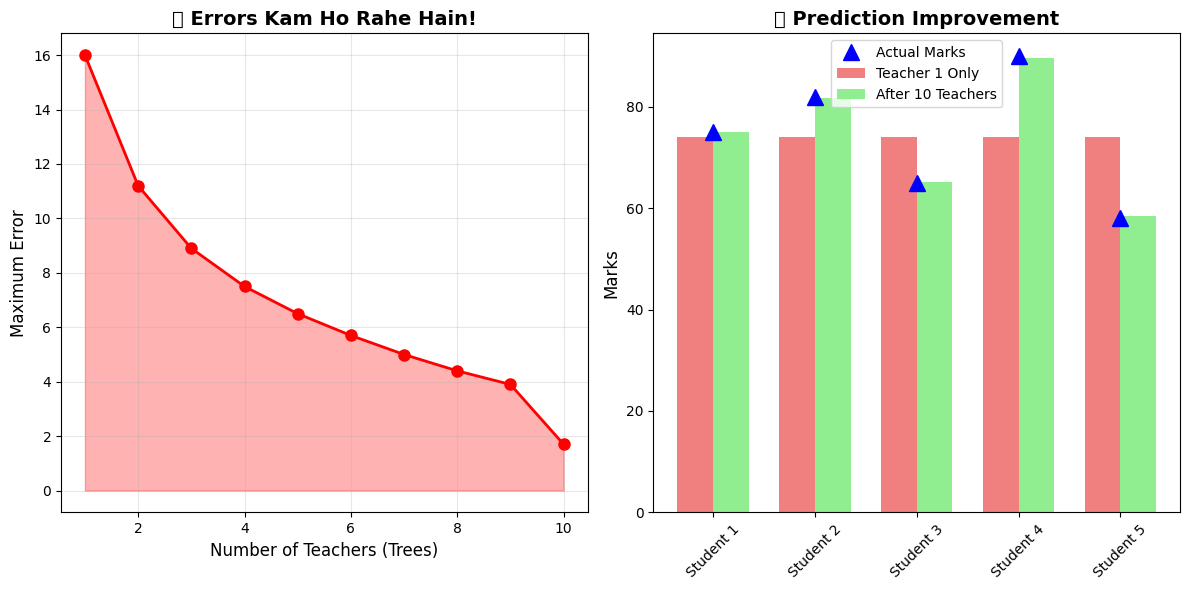


💡 GRAPH SE SAMJHO:
- LEFT GRAPH: Har naye teacher ke saath ERROR KAM hota ja raha hai
- RIGHT GRAPH: Red bars = starting, Green bars = final (closer to blue dots!)


In [27]:
import matplotlib.pyplot as plt

# Data for visualization
steps = list(range(1, 11))
max_errors_over_time = [16.0, 11.2, 8.9, 7.5, 6.5, 5.7, 5.0, 4.4, 3.9, 1.7]

plt.figure(figsize=(12, 6))

# Plot error reduction
plt.subplot(1, 2, 1)
plt.plot(steps, max_errors_over_time, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Number of Teachers (Trees)', fontsize=12)
plt.ylabel('Maximum Error', fontsize=12)
plt.title('❌ Errors Kam Ho Rahe Hain!', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.fill_between(steps, max_errors_over_time, alpha=0.3, color='red')

# Final comparison
plt.subplot(1, 2, 2)
students = ['Student 1', 'Student 2', 'Student 3', 'Student 4', 'Student 5']
x_pos = np.arange(len(students))
width = 0.35

bars1 = plt.bar(x_pos - width/2, [74]*5, width, label='Teacher 1 Only', color='lightcoral')
bars2 = plt.bar(x_pos + width/2, current_pred, width, label='After 10 Teachers', color='lightgreen')

plt.plot(x_pos, actual_marks, 'b^', markersize=12, label='Actual Marks')
plt.xticks(x_pos, students, rotation=45)
plt.ylabel('Marks', fontsize=12)
plt.title('📊 Prediction Improvement', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()

plt.show()

print("\n💡 GRAPH SE SAMJHO:")
print("- LEFT GRAPH: Har naye teacher ke saath ERROR KAM hota ja raha hai")
print("- RIGHT GRAPH: Red bars = starting, Green bars = final (closer to blue dots!)")

In [28]:
# ============================================================
# 🎯 REAL PROBLEM: Kya fruit fresh hai ya rotten?
# Features: Weight (grams), Color Score (1-10), Firmness (1-10)
# ============================================================

import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

print("="*60)
print("🍎 FRUIT QUALITY CLASSIFIER USING XGBOOST")
print("="*60)

# Step 1: DATA BANAO (Simple dataset)
np.random.seed(42)
n_fruits = 200

data = {
    'Weight_g': np.concatenate([
        np.random.normal(150, 20, 100),   # Fresh fruits: heavier
        np.random.normal(120, 25, 100)    # Rotten fruits: lighter
    ]),
    'Color_Score': np.concatenate([
        np.random.normal(8, 1.5, 100),    # Fresh: good color (high score)
        np.random.normal(4, 2, 100)       # Rotten: bad color (low score)
    ]),
    'Firmness': np.concatenate([
        np.random.normal(8, 1.2, 100),    # Fresh: firm
        np.random.normal(3, 1.5, 100)     # Rotten: soft
    ]),
    # Target: 0 = Fresh ✅, 1 = Rotten ❌
    'Is_Rotten': [0]*100 + [1]*100
}

df = pd.DataFrame(data)

print("\n📊 DATASET (First 10 rows):")
print(df.head(10).to_string(index=False))

print(f"\n📈 Dataset Info:")
print(f"Total Fruits: {len(df)}")
print(f"Fresh Fruits: {len(df[df['Is_Rotten']==0])} ✅")
print(f"Rotten Fruits: {len(df[df['Is_Rotten']==1])} ❌")

# Step 2: DATA SPLIT (Train/Test)
X = df[['Weight_g', 'Color_Score', 'Firmness']]
y = df['Is_Rotten']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n✂️ DATA SPLIT:")
print(f"Training fruits: {len(X_train)} (Model ko sikhane ke liye)")
print(f"Testing fruits:  {len(X_test)} (Model test karega)")

🍎 FRUIT QUALITY CLASSIFIER USING XGBOOST

📊 DATASET (First 10 rows):
  Weight_g  Color_Score  Firmness  Is_Rotten
159.934283     8.536681  6.086687          0
147.234714     8.841177  7.280750          0
162.953771     9.624577  8.006292          0
180.460597     9.580703  8.056377          0
145.316933     5.933496  7.459921          0
145.317261     6.593262  8.747420          0
181.584256     8.772553  6.718855          0
165.348695     8.770679  7.829145          0
140.610512     8.772572  8.144355          0
160.851201    13.779097  8.617327          0

📈 Dataset Info:
Total Fruits: 200
Fresh Fruits: 100 ✅
Rotten Fruits: 100 ❌

✂️ DATA SPLIT:
Training fruits: 160 (Model ko sikhane ke liye)
Testing fruits:  40 (Model test karega)
